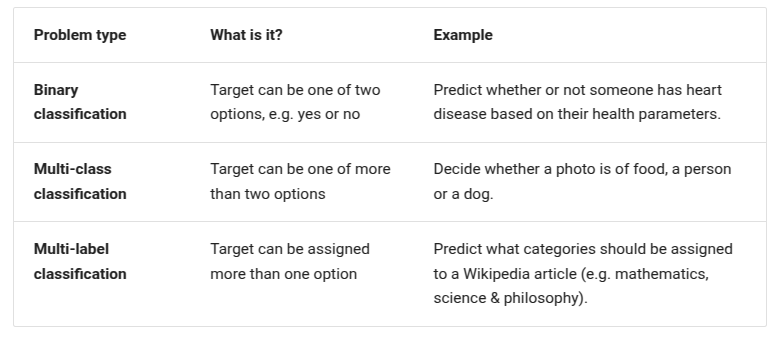

## 0. Architecture of a classification neural network

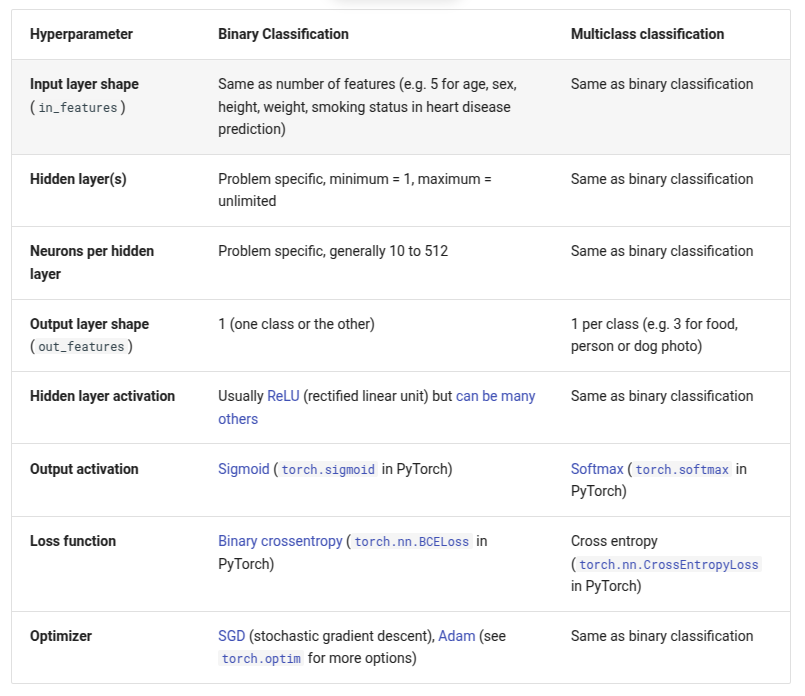

## 1. Make classification data and get it ready

In [1]:
from sklearn.datasets import make_circles


# Make 1000 samples 
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values

In [2]:
print(f"First 5 samples:\n{X[:5]}")
print(f"First 5 labels:\n{y[:5]}")

First 5 samples:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 labels:
[1 1 1 1 0]


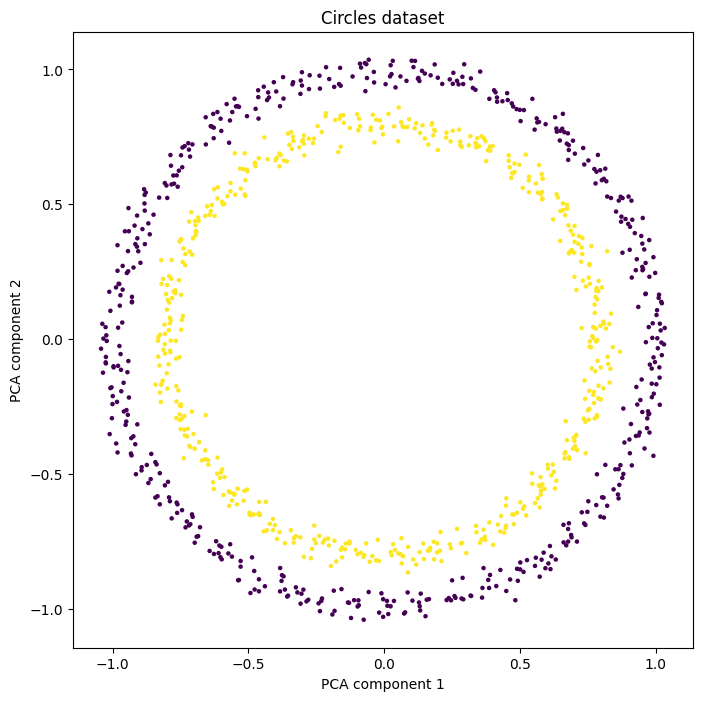

In [3]:
def plot_circles(X, y):
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA

    # Reduce to 2D
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    # Plot the circles
    plt.figure(figsize=(8, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', s=5)
    plt.title("Circles dataset")
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.show()
# Plot the circles
plot_circles(X, y)

### 1.1 Input and output shapes

In [4]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1000, 2)
y shape: (1000,)


In [5]:
X_sample = X[0]
y_sample = y[0]
print(f"X sample shape: {X_sample.shape}")
print(f"y sample shape: {y_sample.shape}")

X sample shape: (2,)
y sample shape: ()


### 1.2 Turn data into tensors and create train and test splits

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

In [7]:
# Turn the data into PyTorch tensors
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).float()

print(f"X: {X[:5]}")
print(f"y: {y[:5]}")

X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
y: [1 1 1 1 0]


In [8]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: torch.Size([800, 2])
y_train shape: torch.Size([800])
X_test shape: torch.Size([200, 2])
y_test shape: torch.Size([200])


In [9]:
# Create Custom Dataset
from torch.utils.data import Dataset, DataLoader

class CircleDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
train_dataset = CircleDataset(X_train, y_train)
test_dataset = CircleDataset(X_test, y_test)

In [11]:
# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Check the DataLoader
for X_batch, y_batch in train_loader:
    print(f"X batch shape: {X_batch.shape}")
    print(f"y batch shape: {y_batch.shape}")
    break

X batch shape: torch.Size([32, 2])
y batch shape: torch.Size([32])


In [12]:
# Define the model
class CircleModelV0(nn.Module):
    def __init__(self, X):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(X.shape[1], 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

In [13]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [14]:
# create an instance of the model
model = CircleModelV0(X_tensor).to(device)
model

CircleModelV0(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [15]:
# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.5655],
        [0.5723],
        [0.5463],
        [0.5699],
        [0.5780],
        [0.5779],
        [0.5739],
        [0.5755],
        [0.5454],
        [0.5727]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup loss function and optimizer

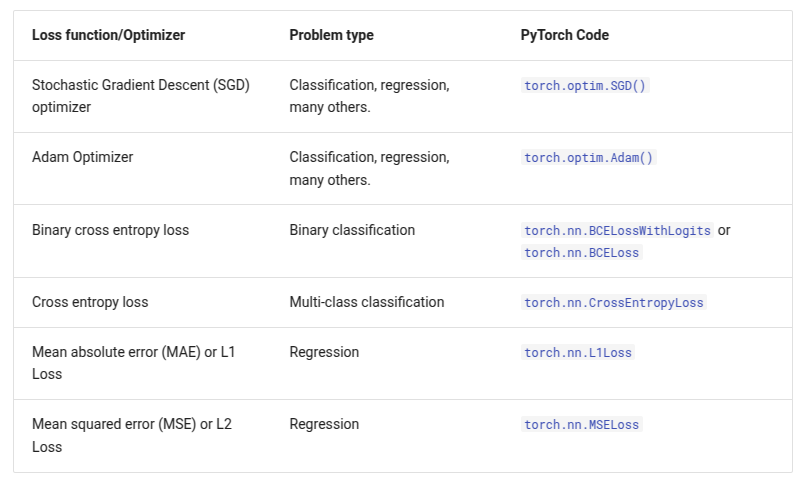

In [26]:
# Create loss function and optimizer
# loss_fn = nn.BCELoss()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

## 3. Train model

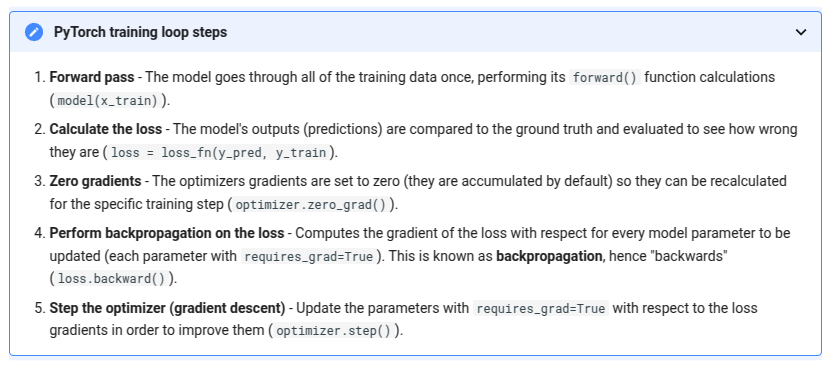

### Building a training and testing loop

In [17]:
# Evaluation function
from sklearn.metrics import accuracy_score

In [27]:
torch.manual_seed(42)

# Set the number of epoches
epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Building training and evaluation loop
#### Training loop
for epoch in range(epochs):
    # Training
    model.train()
    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # Forward Pass
        outputs = model(batch_features)
        # Calculate Loss
        loss = loss_fn(outputs.squeeze(), batch_labels)
        # Calculate Accuracy
        acc = accuracy_score(batch_labels.cpu().detach().numpy(), 
                           outputs.squeeze().cpu().detach().numpy().round())
        # Print Loss and Accuracy
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")
        # Optimizer Zero Grad
        optimizer.zero_grad()
        # Loss Backward
        loss.backward()
        # Optimizer Step
        optimizer.step()
    
    # Evaluation
    model.eval()
    with torch.inference_mode():
        test_preds = model(X_test)
        test_loss = loss_fn(test_preds.squeeze(), y_test)
        test_acc = accuracy_score(y_test.cpu().numpy(),
                                test_preds.squeeze().cpu().numpy().round())
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Test Loss: {test_loss.item():.4f}, Test Accuracy: {test_acc:.4f}")

Epoch: 0, Loss: 0.5032, Accuracy: 1.0000
Epoch: 0, Loss: 0.5076, Accuracy: 1.0000
Epoch: 0, Loss: 0.5151, Accuracy: 1.0000
Epoch: 0, Loss: 0.4914, Accuracy: 1.0000
Epoch: 0, Loss: 0.4845, Accuracy: 1.0000
Epoch: 0, Loss: 0.4680, Accuracy: 1.0000
Epoch: 0, Loss: 0.4566, Accuracy: 1.0000
Epoch: 0, Loss: 0.5695, Accuracy: 0.9688
Epoch: 0, Loss: 0.5270, Accuracy: 1.0000
Epoch: 0, Loss: 0.5391, Accuracy: 1.0000
Epoch: 0, Loss: 0.5033, Accuracy: 1.0000
Epoch: 0, Loss: 0.4680, Accuracy: 1.0000
Epoch: 0, Loss: 0.4441, Accuracy: 1.0000
Epoch: 0, Loss: 0.4677, Accuracy: 1.0000
Epoch: 0, Loss: 0.5395, Accuracy: 1.0000
Epoch: 0, Loss: 0.4563, Accuracy: 1.0000
Epoch: 0, Loss: 0.5169, Accuracy: 1.0000
Epoch: 0, Loss: 0.5646, Accuracy: 1.0000
Epoch: 0, Loss: 0.5058, Accuracy: 1.0000
Epoch: 0, Loss: 0.5865, Accuracy: 1.0000
Epoch: 0, Loss: 0.5193, Accuracy: 1.0000
Epoch: 0, Loss: 0.4558, Accuracy: 1.0000
Epoch: 0, Loss: 0.4917, Accuracy: 1.0000
Epoch: 0, Loss: 0.5270, Accuracy: 1.0000
Epoch: 0, Loss: 

## 4. Make predictions and evaluate the model

In [22]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

In [24]:
import matplotlib.pyplot as plt

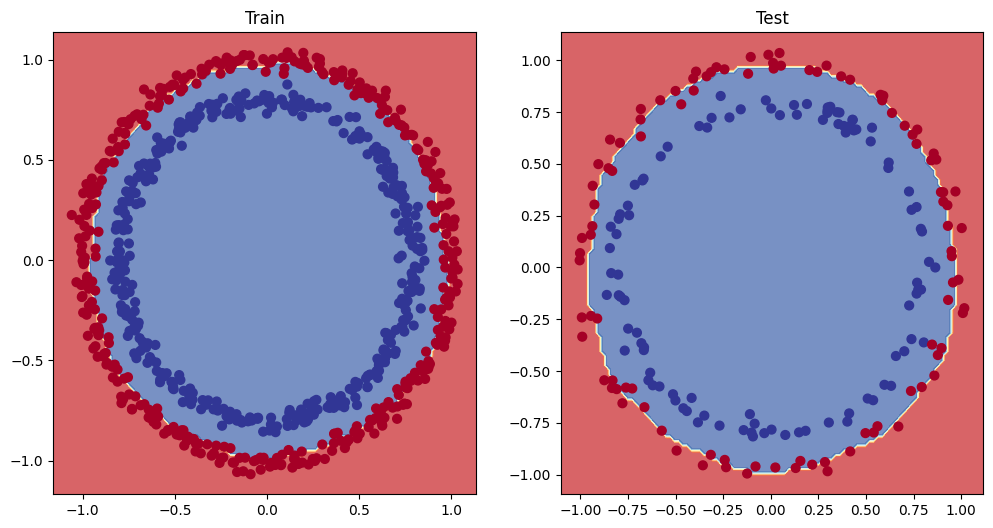

In [28]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

## 5. Improving a model (from a model perspective)

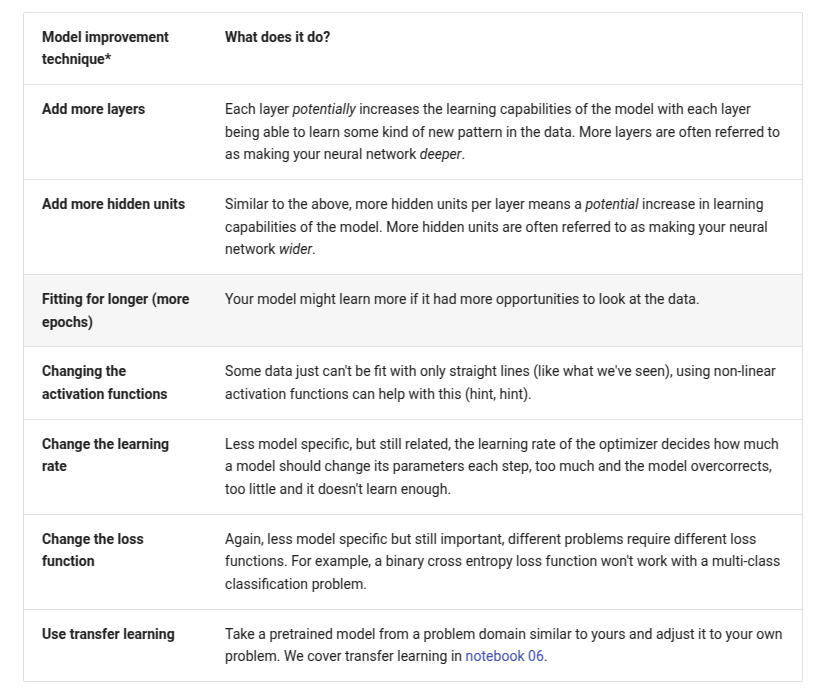

# Creating multi-class classification data

In [29]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [30]:
# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

In [31]:
# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels 
    cluster_std=1.5, # give the clusters a little shake up (try changing this to 1.0, the default)
    random_state=RANDOM_SEED
)

In [32]:
# 2. Turn the data into tensors
X_blob_tensor = torch.from_numpy(X_blob).float()
y_blob_tensor = torch.from_numpy(y_blob).long()
print(f"X_blob shape: {X_blob.shape}")
print(f"y_blob shape: {y_blob.shape}")

X_blob shape: (1000, 2)
y_blob shape: (1000,)


In [33]:
# 3. Split the data into training and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob_tensor, y_blob_tensor, test_size=0.2, random_state=RANDOM_SEED)

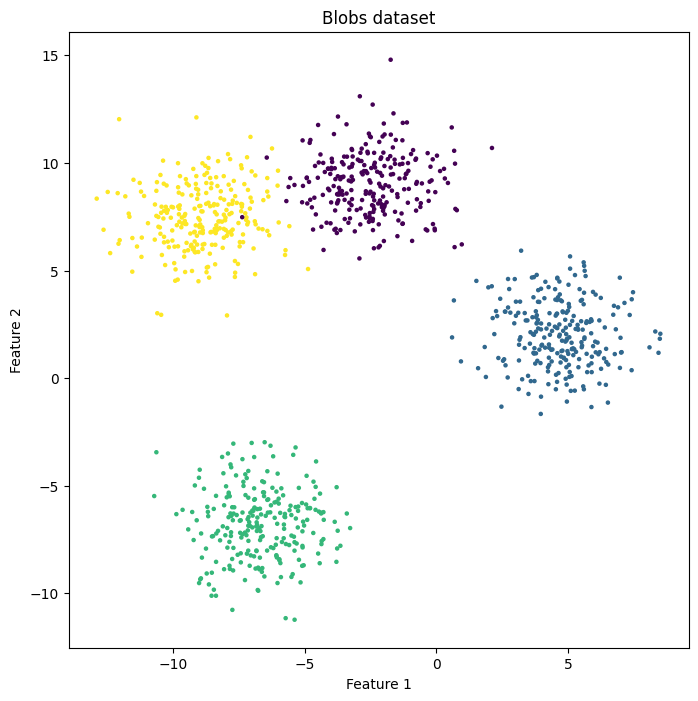

In [34]:
# 4. Plot the data
def plot_blob_data(X, y):
    plt.figure(figsize=(8, 8))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=5)
    plt.title("Blobs dataset")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
plot_blob_data(X_blob, y_blob)

In [35]:
# 5. Create Custom Dataset
from torch.utils.data import Dataset, DataLoader
class BlobDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
# Create train and test datasets
train_blob_dataset = BlobDataset(X_blob_train, y_blob_train)
test_blob_dataset = BlobDataset(X_blob_test, y_blob_test)
# Create DataLoader
train_blob_loader = DataLoader(train_blob_dataset, batch_size=32, shuffle=True)
test_blob_loader = DataLoader(test_blob_dataset, batch_size=32, shuffle=False)
# Check the DataLoader
for X_batch, y_batch in train_blob_loader:
    print(f"X batch shape: {X_batch.shape}")
    print(f"y batch shape: {y_batch.shape}")
    break

X batch shape: torch.Size([32, 2])
y batch shape: torch.Size([32])


In [36]:
# 6. Define the model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_features)
        )
    def forward(self, x):
        return self.model(x)

In [38]:
# 7. Create an instance of the model
input_features = NUM_FEATURES
output_features = NUM_CLASSES
model_blob = BlobModel(input_features, output_features).to(device)
model_blob

BlobModel(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=4, bias=True)
  )
)

In [39]:
# 8. Create loss function and optimizer
loss_fn_blob = nn.CrossEntropyLoss()
optimizer_blob = optim.Adam(model_blob.parameters(), lr=0.01)

In [40]:
# Fit the model
torch.manual_seed(42)

# Set the number of epoches
epochs_blob = 100
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# Building training and evaluation loop
#### Training loop
for epoch in range(epochs_blob):
    model_blob.train()
    for batch_features, batch_labels in train_blob_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        # Forward Pass
        outputs = model_blob(batch_features)
        # Calculate Loss
        loss = loss_fn_blob(outputs, batch_labels)
        # Print Loss and Accuracy
        if epoch % 10 == 0:
            acc = accuracy_score(batch_labels.cpu().detach().numpy(), 
                           outputs.argmax(dim=1).cpu().detach().numpy())
            print(f"Epoch: {epoch}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")
        # Optimizer Zero Grad
        optimizer_blob.zero_grad()
        # Loss Backward
        loss.backward()
        # Optimizer Step
        optimizer_blob.step()
    # Evaluation
    model_blob.eval()
    with torch.inference_mode():
        test_preds = model_blob(X_blob_test)
        test_loss = loss_fn_blob(test_preds, y_blob_test)
        test_acc = accuracy_score(y_blob_test.cpu().numpy(),
                                test_preds.argmax(dim=1).cpu().numpy())
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Test Loss: {test_loss.item():.4f}, Test Accuracy: {test_acc:.4f}")

Epoch: 0, Loss: 1.6448, Accuracy: 0.1875
Epoch: 0, Loss: 0.9424, Accuracy: 0.5938
Epoch: 0, Loss: 0.8123, Accuracy: 0.8750
Epoch: 0, Loss: 0.5580, Accuracy: 0.9062
Epoch: 0, Loss: 0.4122, Accuracy: 0.8438
Epoch: 0, Loss: 0.2816, Accuracy: 0.9688
Epoch: 0, Loss: 0.2367, Accuracy: 1.0000
Epoch: 0, Loss: 0.1138, Accuracy: 1.0000
Epoch: 0, Loss: 0.0834, Accuracy: 1.0000
Epoch: 0, Loss: 0.0988, Accuracy: 0.9688
Epoch: 0, Loss: 0.0337, Accuracy: 1.0000
Epoch: 0, Loss: 0.0603, Accuracy: 1.0000
Epoch: 0, Loss: 0.1756, Accuracy: 0.9688
Epoch: 0, Loss: 0.0165, Accuracy: 1.0000
Epoch: 0, Loss: 0.0289, Accuracy: 1.0000
Epoch: 0, Loss: 0.0223, Accuracy: 1.0000
Epoch: 0, Loss: 0.0174, Accuracy: 1.0000
Epoch: 0, Loss: 0.0365, Accuracy: 1.0000
Epoch: 0, Loss: 0.0984, Accuracy: 0.9688
Epoch: 0, Loss: 0.0121, Accuracy: 1.0000
Epoch: 0, Loss: 0.0088, Accuracy: 1.0000
Epoch: 0, Loss: 0.0047, Accuracy: 1.0000
Epoch: 0, Loss: 0.0197, Accuracy: 1.0000
Epoch: 0, Loss: 0.0837, Accuracy: 0.9375
Epoch: 0, Loss: 

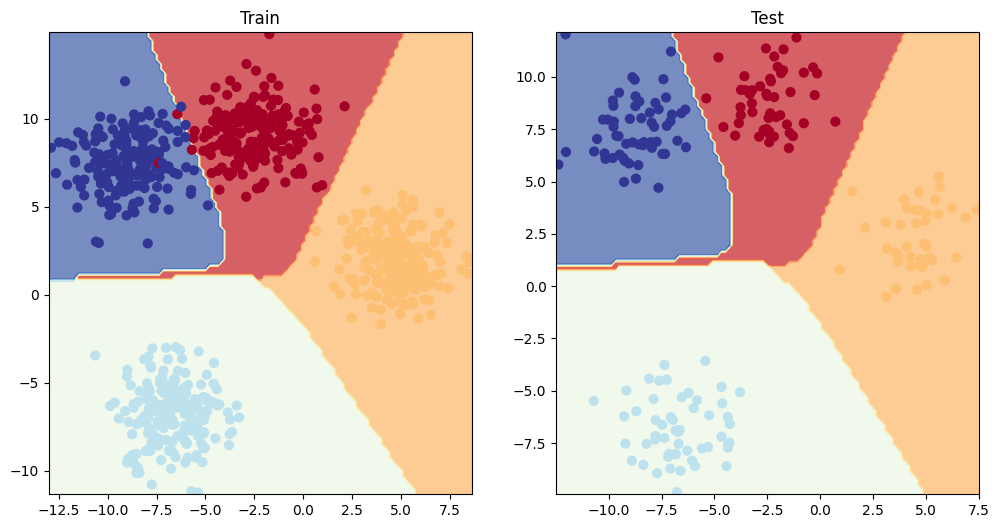

In [41]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_blob, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_blob, X_blob_test, y_blob_test)

### More classification evaluation metrics

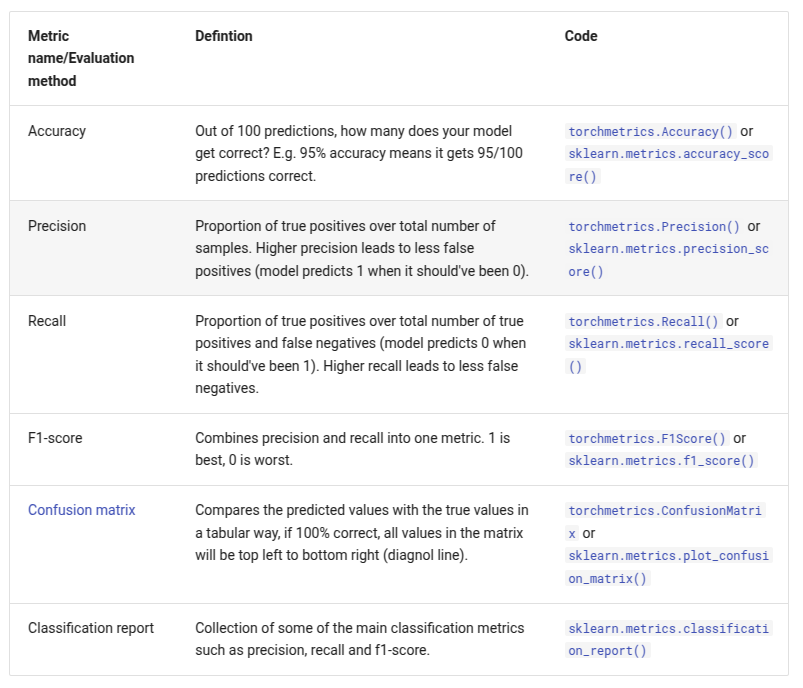